Import Dataset

In [17]:
import pandas as pd
!git clone https://github.com/zhangjingwen713-jpg/MSSP6070.git
%cd MSSP6070
df = pd.read_csv('data/InternetSales.csv', encoding='latin1')

Cloning into 'MSSP6070'...
remote: Enumerating objects: 202, done.
remote: Counting objects: 100% (202/202), done.
remote: Compressing objects: 100% (174/174), done.
remote: Total 202 (delta 85), reused 45 (delta 20), pack-reused 0 (from 0)
Receiving objects: 100% (202/202), 8.64 MiB | 5.78 MiB/s, done.
Resolving deltas: 100% (85/85), done.
/content/MSSP6070/MSSP6070


/tmp/ipython-input-1343757649.py:4: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/InternetSales.csv', encoding='latin1')


Internet sales of Adventure Works by year for each Country Region

In [2]:
df['OrderDate'] = pd.to_datetime(df['OrderDate'])
df['Year'] = df['OrderDate'].dt.year
salesbyyearforcountry = df.groupby(['CountryRegionCode', 'Year'])['SalesAmount'].sum().reset_index()
print(salesbyyearforcountry)

   CountryRegionCode  Year   SalesAmount
0                 AU  2010  2.090978e+04
1                 AU  2011  2.563732e+06
2                 AU  2012  2.128407e+06
3                 AU  2013  4.339443e+06
4                 AU  2014  8.507720e+03
5                 CA  2010  3.578270e+03
6                 CA  2011  5.715718e+05
7                 CA  2012  3.076045e+05
8                 CA  2013  1.085633e+06
9                 CA  2014  9.457620e+03
10                DE  2011  5.205002e+05
11                DE  2012  6.086580e+05
12                DE  2013  1.761876e+06
13                DE  2014  3.277830e+03
14                FR  2010  3.399990e+03
15                FR  2011  4.108453e+05
16                FR  2012  6.480655e+05
17                FR  2013  1.578512e+06
18                FR  2014  3.195060e+03
19                GB  2010  6.990982e+02
20                GB  2011  5.505912e+05
21                GB  2012  7.127010e+05
22                GB  2013  2.124007e+06
23              

Generate summary statistics for Yearly Income, Gender by Country Regions

In [3]:
yearlyincomesummary = df.groupby(['CountryRegionCode', 'Gender'])['YearlyIncome'].agg(['min', 'max', 'std', 'mean', 'median']).reset_index()
print(yearlyincomesummary)

   CountryRegionCode Gender    min     max           std          mean  \
0                 AU      F  10000  160000  30613.956169  67060.583396   
1                 AU      M  10000  170000  32550.778171  65412.912913   
2                 CA      F  10000  170000  19435.158438  58651.315789   
3                 CA      M  10000  170000  22702.851581  61460.221551   
4                 DE      F  10000  130000  37622.814569  48287.234043   
5                 DE      M  10000  130000  37487.619366  46730.837790   
6                 FR      F  10000  110000  28421.836245  39367.134124   
7                 FR      M  10000  110000  28665.660622  39805.545553   
8                 GB      F  10000  170000  51130.689140  56518.670979   
9                 GB      M  10000  170000  50963.707551  55771.754636   
10                US      F  10000  170000  25498.805483  64766.897585   
11                US      M  10000  170000  26520.348175  65450.196961   

     median  
0   70000.0  
1   70000

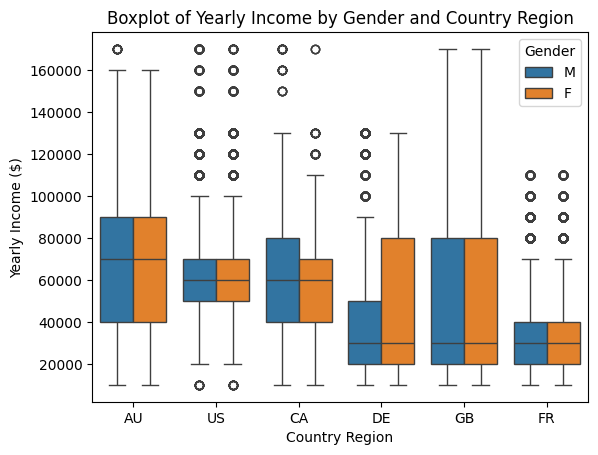

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(data=df, x='CountryRegionCode', y='YearlyIncome', hue='Gender')
plt.title('Boxplot of Yearly Income by Gender and Country Region')
plt.xlabel('Country Region')
plt.ylabel('Yearly Income ($)')
plt.savefig('Graph2.png', dpi=300, bbox_inches='tight')
plt.show()
from google.colab import files
files.download('Graph2.png')

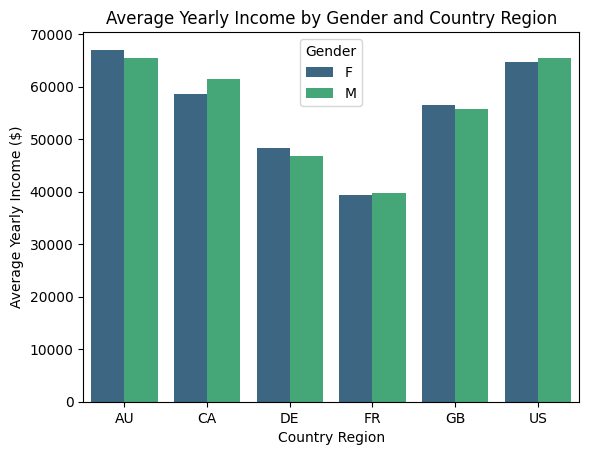

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [7]:
mean = df.groupby(['CountryRegionCode', 'Gender'])['YearlyIncome'].mean().reset_index()
sns.barplot(data=mean, x='CountryRegionCode', y='YearlyIncome', hue='Gender', palette='viridis')
plt.title('Average Yearly Income by Gender and Country Region')
plt.xlabel('Country Region')
plt.ylabel('Average Yearly Income ($)')
plt.legend(title='Gender')
plt.savefig('Graph3.png', dpi=300, bbox_inches='tight')
plt.show()
from google.colab import files
files.download('Graph3.png')

Average Price of the Product Category that Generates the most Sales

In [5]:
def categorize_product(price):
    if price > 500:
        return 'Bicycles'
    elif 100 <= price <= 500:
        return 'Bicycle Racks'
    elif 0 <= price < 100:
        return 'Accessories'
df['ProductCategory'] = df['UnitPrice'].apply(categorize_product)
df['ProductCategory'].value_counts()

,count
ProductCategory,
Accessories,44616
Bicycles,15205
Bicycle Racks,577


In [7]:
categorysales = df.groupby('ProductCategory')['SalesAmount'].sum().reset_index().sort_values(by='SalesAmount', ascending=False)
print(categorysales)
highestcategory = categorysales.loc[categorysales['SalesAmount'].idxmax(), 'ProductCategory']
meanprice = df[df['ProductCategory'] == highestcategory]['UnitPrice'].mean()
print(highestcategory)
print(meanprice)

  ProductCategory   SalesAmount
2        Bicycles  2.831814e+07
0     Accessories  9.615816e+05
1   Bicycle Racks  7.895100e+04
Bicycles
1862.4231930746462


/tmp/ipython-input-1141687273.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=categorysales, x='ProductCategory', y='SalesAmount', palette='viridis')


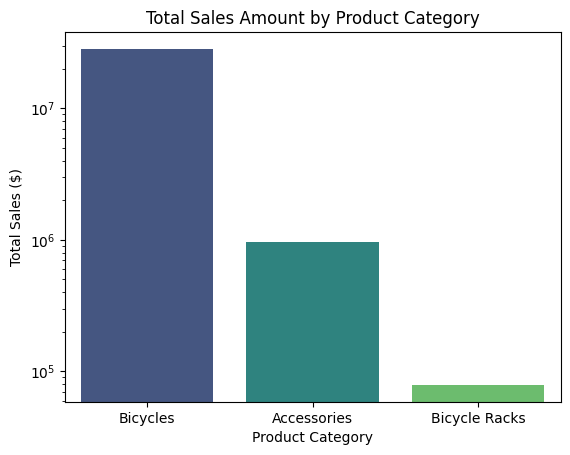

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
sns.barplot(data=categorysales, x='ProductCategory', y='SalesAmount', palette='viridis')
plt.title('Total Sales Amount by Product Category')
plt.yscale('log')
plt.xlabel('Product Category')
plt.ylabel('Total Sales ($)')
plt.savefig('Graph4.png', dpi=300, bbox_inches='tight')
plt.show()
from google.colab import files
files.download('Graph4.png')

Does owning home make a difference in sales

In [16]:
homesales = df.groupby('HouseOwnerFlag')['SalesAmount'].agg(['count','mean', 'median', 'sum']).reset_index()
homesales['HouseOwnerFlag'] = homesales['HouseOwnerFlag'].replace({1: 'Owns Home', 0: 'Does Not Own Home'})
print(homesales)

      HouseOwnerFlag  count        mean  median           sum
0  Does Not Own Home  18699  479.882744   29.99  8.973327e+06
1          Owns Home  41699  488.869033   32.60  2.038535e+07
